Task 2: Content Type Analysis Dashboard

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
#Step 1:Load the cleaned dataset
df=pd.read_csv(r"netflix_cleaned.csv")
df.head()

,show_id,type,title,director,country,date_added,release_year,rating,duration,listed_in
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,United States,2021-09-25,2020,PG-13,90 min,Documentaries
1,s3,TV Show,Ganglands,Julien Leclercq,France,2021-09-24,2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act..."
2,s6,TV Show,Midnight Mass,Mike Flanagan,United States,2021-09-24,2021,TV-MA,1 Season,"TV Dramas, TV Horror, TV Mysteries"
3,s14,Movie,Confessions of an Invisible Girl,Bruno Garotti,Brazil,2021-09-22,2021,TV-PG,91 min,"Children & Family Movies, Comedies"
4,s8,Movie,Sankofa,Haile Gerima,United States,2021-09-24,1993,TV-MA,125 min,"Dramas, Independent Movies, International Movies"


In [3]:
#Step 2: Calculate the total number of Movies and TV Shows
df["type"].unique()

array(['Movie', 'TV Show'], dtype=object)

In [4]:
#total movies and tv shows
content_counts = df["type"].value_counts()
print(content_counts)

type
Movie      6126
TV Show    2664
Name: count, dtype: int64


In [5]:
#Content percentage
content_percentage = df["type"].value_counts(normalize=True) * 100
print("Content Percentage:",content_percentage.round(2))

Content Percentage: type
Movie      69.69
TV Show    30.31
Name: proportion, dtype: float64


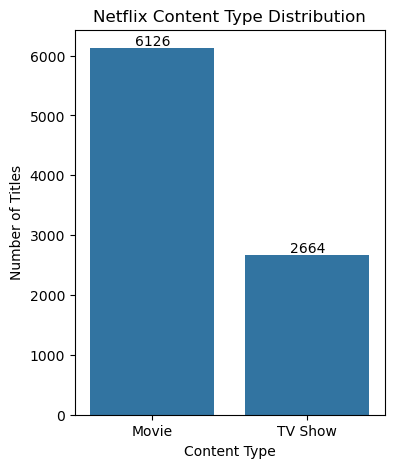

In [6]:
#Step 3: Create visualizations for content distribution

#Bar Chart — Movies vs TV Shows
plt.figure(figsize=(4, 5))

ax = sns.barplot(x=content_counts.index,y=content_counts.values)
plt.title("Netflix Content Type Distribution")
plt.xlabel("Content Type")
plt.ylabel("Number of Titles")

for container in ax.containers:
    ax.bar_label(container)
plt.show()

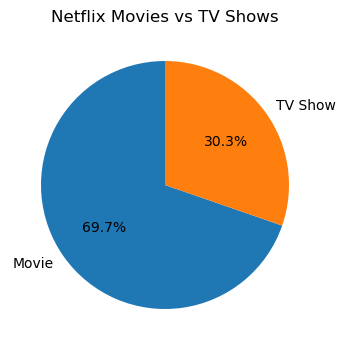

In [7]:
#Pie Chart — Content Proportion
plt.figure(figsize=(4,5))

plt.pie(content_counts.values,labels=content_counts.index,autopct="%1.1f%%",
    startangle=90)

plt.title("Netflix Movies vs TV Shows")
plt.show()

In [8]:
#Step 4: Compare Content Proportions

#Calculate the percentage
content_summary = pd.DataFrame({"Count": df["type"].value_counts(),
    "Percentage": df["type"].value_counts(normalize=True) * 100})
content_summary["Percentage"] = content_summary["Percentage"].round(2)
print(content_summary)

         Count  Percentage
type                      
Movie     6126       69.69
TV Show   2664       30.31


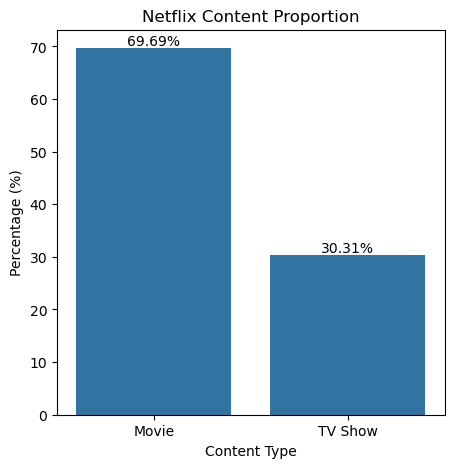

In [9]:
#Create a comparison chart
plt.figure(figsize=(5, 5))

ax = sns.barplot(x=content_summary.index,y=content_summary["Percentage"])

plt.title("Netflix Content Proportion")
plt.xlabel("Content Type")
plt.ylabel("Percentage (%)")
for container in ax.containers:
    ax.bar_label(container, fmt="%.2f%%")

plt.show()

In [10]:
#Calculate the difference
movie_count = content_summary.loc["Movie", "Count"]
tv_show_count = content_summary.loc["TV Show", "Count"]

difference = movie_count - tv_show_count
print("Difference between Movies and TV Shows:", difference)

Difference between Movies and TV Shows: 3462


In [11]:
#Calculate the Movie-to-TV Show ratio
ratio = movie_count / tv_show_count
print("Movie-to-TV Show ratio:", round(ratio, 2))

Movie-to-TV Show ratio: 2.3


#Step 5 — Summarize Key Findings

Key Findings: The analysis shows that Movies make up a larger proportion of the Netflix dataset than TV Shows. There is a difference of 3,462 titles between the two content types, with approximately 2.3 Movies available for every 1 TV Show. This indicates that Movies represent the majority of the content in the analyzed dataset.